In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
df1:pd.DataFrame=pd.read_csv('idealista18_1.csv')
df2:pd.DataFrame=pd.read_csv('idealista18_2.csv')
df:pd.DataFrame=pd.concat([df1,df2],ignore_index=True).drop_duplicates()

In [125]:
original:pd.DataFrame=pd.concat([df1,df2],ignore_index=True).drop_duplicates()

In [21]:
pd.set_option("display.max_columns", None)
df

,ASSETID,PERIOD,PRICE,UNITPRICE,ADTYPOLOGYID,ADOPERATIONID,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,AMENITYID,HASPARKINGSPACE,ISPARKINGSPACEINCLUDEDINPRICE,PARKINGSPACEPRICE,HASNORTHORIENTATION,HASSOUTHORIENTATION,HASEASTORIENTATION,HASWESTORIENTATION,HASBOXROOM,HASWARDROBE,HASSWIMMINGPOOL,HASDOORMAN,HASGARDEN,ISDUPLEX,ISSTUDIO,ISINTOPFLOOR,CONSTRUCTIONYEAR,FLOORCLEAN,FLATLOCATIONID,CADCONSTRUCTIONYEAR,CADMAXBUILDINGFLOOR,CADDWELLINGCOUNT,CADASTRALQUALITYID,BUILTTYPEID_1,BUILTTYPEID_2,BUILTTYPEID_3,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME,ADTYPOLOGY,ADOPERATION
0,A12377633511549727658,201812,109000,1730.158730,HOME,SALE,63,3,1,1,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1965.0,3.0,1.0,1965,5,22,7.0,0,0,1,4.166611,0.313529,2.814425,-3.726785,40.383510,Madrid,HOME,SALE
1,A7691539882862170545,201809,155000,2384.615385,HOME,SALE,65,2,1,0,1,1,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,4.0,1.0,1967,6,79,6.0,0,0,1,4.477237,0.109565,2.934052,-3.726764,40.380375,Madrid,HOME,SALE
2,A4316988685482817826,201809,158000,2025.641026,HOME,SALE,78,3,1,1,1,1,3,0,0,1,0,1,1,1,0,1,0,0,0,0,0,0,NaN,2.0,1.0,1955,4,15,6.0,0,0,1,4.294954,0.217547,2.788894,-3.725683,40.381796,Madrid,HOME,SALE
3,A12032801997263349694,201812,126000,1680.000000,HOME,SALE,75,3,1,1,1,1,3,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,1971.0,2.0,1.0,1971,5,11,6.0,0,0,1,4.861939,0.355738,3.455590,-3.732578,40.378816,Madrid,HOME,SALE
4,A16032891972289007994,201803,184000,1840.000000,HOME,SALE,100,3,2,1,1,1,3,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,NaN,1.0,1.0,1968,5,15,6.0,0,0,1,4.786463,0.395206,3.399424,-3.732196,40.379431,Madrid,HOME,SALE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189918,A5469264850873866443,201809,72000,1142.857143,HOME,SALE,63,2,1,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,NaN,3.0,1.0,1968,5,11,6.0,0,1,0,4.829951,0.385920,3.421160,-3.732238,40.378998,Madrid,HOME,SALE
189919,A711055539203140082,201809,136000,1360.000000,HOME,SALE,100,3,2,1,0,1,3,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,NaN,3.0,1.0,1987,7,29,5.0,0,0,1,5.363864,0.155790,3.866306,-3.735504,40.374896,Madrid,HOME,SALE
189920,A4740286493963203916,201812,119000,1676.056338,HOME,SALE,71,3,1,0,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,1955,4,17,5.0,0,0,1,3.999653,0.354627,2.489760,-3.722853,40.383724,Madrid,HOME,SALE
189921,A15722582369407807529,201809,96000,1500.000000,HOME,SALE,64,3,1,1,1,0,3,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1970.0,3.0,2.0,1970,7,21,6.0,0,1,0,4.574522,0.151881,3.005669,-3.727214,40.379570,Madrid,HOME,SALE


In [126]:
unicos:pd.Series=df.nunique(dropna=False)
tipos:pd.Series=df.dtypes
nnans:pd.Series=df.isna().sum().sort_values(ascending=False)
constantes=unicos[unicos==1].keys()
binarios=unicos[unicos==2].keys()
nans=nnans[nnans>0].keys()

In [127]:
nans

Index(['CONSTRUCTIONYEAR', 'FLATLOCATIONID', 'FLOORCLEAN',
       'CADASTRALQUALITYID'],
      dtype='str')

In [128]:
df=df.drop(columns=constantes)

In [129]:
df=df.assign(
    BUILTTYPEID=np.select(
        [df['BUILTTYPEID_1']==1,df['BUILTTYPEID_2']==1,df['BUILTTYPEID_3']==1],
        [1,2,3]
    )
)

In [130]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189923 entries, 0 to 189922
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ASSETID                        189923 non-null  str    
 1   PERIOD                         189923 non-null  int64  
 2   PRICE                          189923 non-null  int64  
 3   UNITPRICE                      189923 non-null  float64
 4   CONSTRUCTEDAREA                189923 non-null  int64  
 5   ROOMNUMBER                     189923 non-null  int64  
 6   BATHNUMBER                     189923 non-null  int64  
 7   HASTERRACE                     189923 non-null  int64  
 8   HASLIFT                        189923 non-null  int64  
 9   HASAIRCONDITIONING             189923 non-null  int64  
 10  AMENITYID                      189923 non-null  int64  
 11  HASPARKINGSPACE                189923 non-null  int64  
 12  ISPARKINGSPACEINCLUDEDINPRICE  189923 non

In [131]:
df

,ASSETID,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,AMENITYID,HASPARKINGSPACE,ISPARKINGSPACEINCLUDEDINPRICE,PARKINGSPACEPRICE,HASNORTHORIENTATION,HASSOUTHORIENTATION,HASEASTORIENTATION,HASWESTORIENTATION,HASBOXROOM,HASWARDROBE,HASSWIMMINGPOOL,HASDOORMAN,HASGARDEN,ISDUPLEX,ISSTUDIO,ISINTOPFLOOR,CONSTRUCTIONYEAR,FLOORCLEAN,FLATLOCATIONID,CADCONSTRUCTIONYEAR,CADMAXBUILDINGFLOOR,CADDWELLINGCOUNT,CADASTRALQUALITYID,BUILTTYPEID_1,BUILTTYPEID_2,BUILTTYPEID_3,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME,BUILTTYPEID
0,A12377633511549727658,201812,109000,1730.158730,63,3,1,1,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1965.0,3.0,1.0,1965,5,22,7.0,0,0,1,4.166611,0.313529,2.814425,-3.726785,40.383510,Madrid,3
1,A7691539882862170545,201809,155000,2384.615385,65,2,1,0,1,1,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,4.0,1.0,1967,6,79,6.0,0,0,1,4.477237,0.109565,2.934052,-3.726764,40.380375,Madrid,3
2,A4316988685482817826,201809,158000,2025.641026,78,3,1,1,1,1,3,0,0,1,0,1,1,1,0,1,0,0,0,0,0,0,NaN,2.0,1.0,1955,4,15,6.0,0,0,1,4.294954,0.217547,2.788894,-3.725683,40.381796,Madrid,3
3,A12032801997263349694,201812,126000,1680.000000,75,3,1,1,1,1,3,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,1971.0,2.0,1.0,1971,5,11,6.0,0,0,1,4.861939,0.355738,3.455590,-3.732578,40.378816,Madrid,3
4,A16032891972289007994,201803,184000,1840.000000,100,3,2,1,1,1,3,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,NaN,1.0,1.0,1968,5,15,6.0,0,0,1,4.786463,0.395206,3.399424,-3.732196,40.379431,Madrid,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189918,A5469264850873866443,201809,72000,1142.857143,63,2,1,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,NaN,3.0,1.0,1968,5,11,6.0,0,1,0,4.829951,0.385920,3.421160,-3.732238,40.378998,Madrid,2
189919,A711055539203140082,201809,136000,1360.000000,100,3,2,1,0,1,3,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,NaN,3.0,1.0,1987,7,29,5.0,0,0,1,5.363864,0.155790,3.866306,-3.735504,40.374896,Madrid,3
189920,A4740286493963203916,201812,119000,1676.056338,71,3,1,0,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0.0,NaN,1955,4,17,5.0,0,0,1,3.999653,0.354627,2.489760,-3.722853,40.383724,Madrid,3
189921,A15722582369407807529,201809,96000,1500.000000,64,3,1,1,1,0,3,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1970.0,3.0,2.0,1970,7,21,6.0,0,1,0,4.574522,0.151881,3.005669,-3.727214,40.379570,Madrid,2


In [132]:
df['PERIOD'].value_counts()

PERIOD
201812    81622
201803    49051
201809    33992
201806    25258
Name: count, dtype: int64

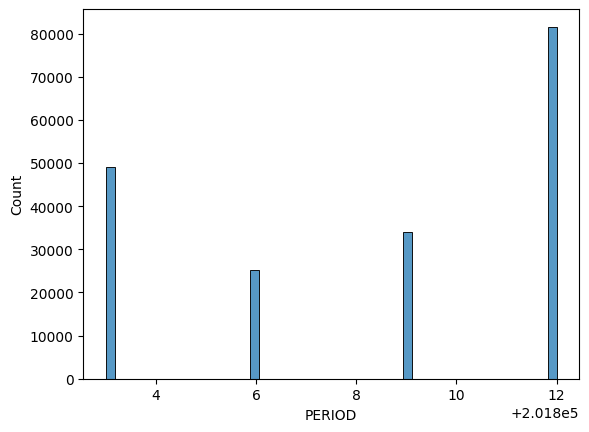

In [133]:
sns.histplot(
    x='PERIOD',
    data=df,
    bins=50,
)
plt.show()

<Axes: xlabel='CITYNAME', ylabel='PRICE'>

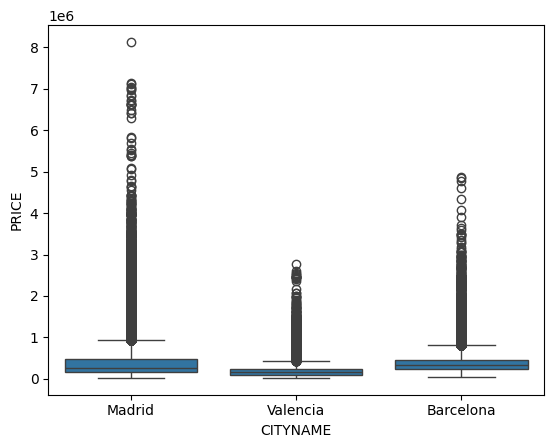

In [134]:
precios=df['PRICE']
k=1.5
media_precio=precios.mean()
q1=np.quantile(precios,q=0.25)
q3=np.quantile(precios,q=0.75)
iqr=q3-q1
lim_i=q1-iqr*k
lim_s=q3+iqr*k
sns.boxplot(
    x='CITYNAME',
    y='PRICE',
    data=df
)

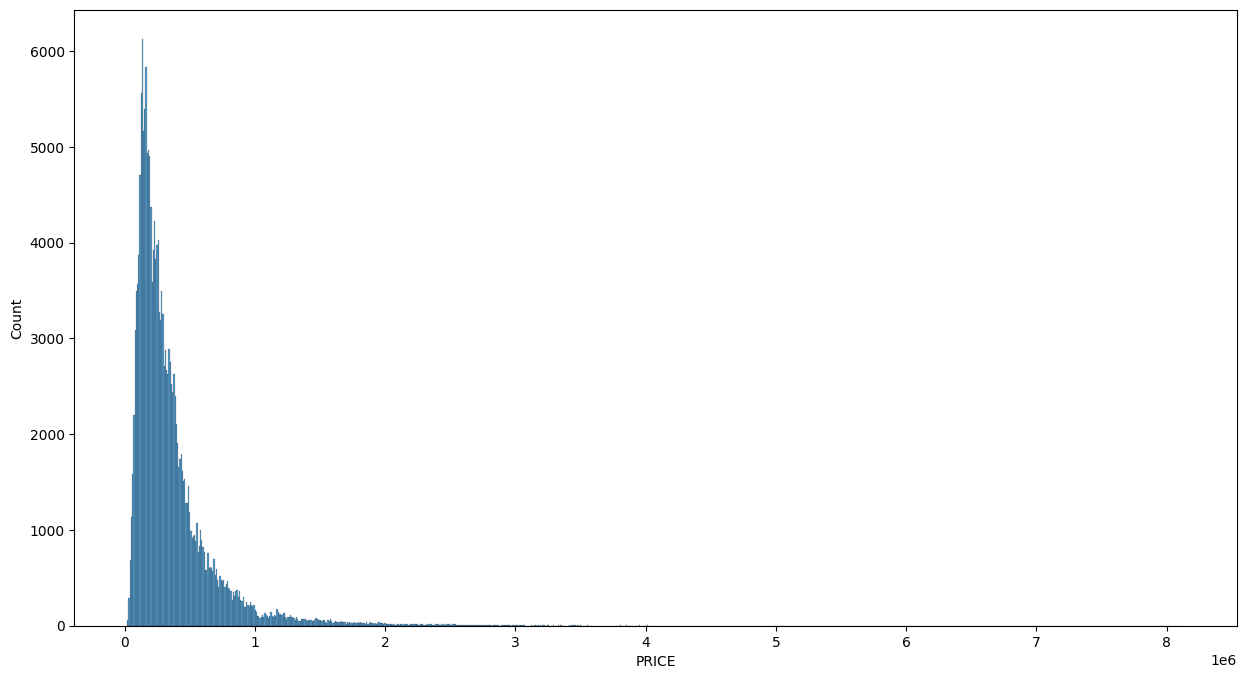

In [135]:
plt.figure(figsize=(15,8))
sns.histplot(
    x='PRICE',
    data=df
)
plt.show()

<Axes: xlabel='UNITPRICE', ylabel='Count'>

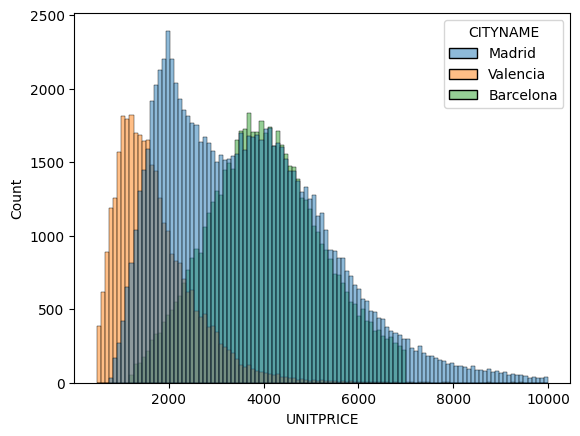

In [136]:
sns.histplot(
    x='UNITPRICE',
    hue='CITYNAME',
    data=df,
)

In [137]:
nulos_conteo = df.isnull().sum()
# shape devuelve una tupla (filas, columnas), y con [0] cogemos solo las filas
nulos_porcentaje = (df.isnull().sum() / df.shape[0]) * 100

# Creamos una tabla nueva con las dos cosas juntas para verlo más claro
tabla_nulos = pd.DataFrame({
    "nulos":       nulos_conteo,        # columna con el número de nulos
    "porcentaje":  nulos_porcentaje     # columna con el porcentaje
})

tabla_nulos = tabla_nulos.sort_values("porcentaje", ascending=False)

tabla_nulos[tabla_nulos["nulos"] > 0]

nulos_usuario   = df["CONSTRUCTIONYEAR"].isnull().sum()
nulos_catastro  = df["CADCONSTRUCTIONYEAR"].isnull().sum()
total_filas     = len(df)

print(f"Nulos en CONSTRUCTIONYEAR :    {nulos_usuario}  ({nulos_usuario/total_filas*100:.2f}%)")
print(f"Nulos en CADCONSTRUCTIONYEAR : {nulos_catastro}  ({nulos_catastro/total_filas*100:.2f}%)")
nulos_usuario   = df["CONSTRUCTIONYEAR"].isnull().sum()
nulos_catastro  = df["CADCONSTRUCTIONYEAR"].isnull().sum()
total_filas     = len(df)

print(f"Nulos en CONSTRUCTIONYEAR :    {nulos_usuario}  ({nulos_usuario/total_filas*100:.2f}%)")
print(f"Nulos en CADCONSTRUCTIONYEAR: {nulos_catastro}  ({nulos_catastro/total_filas*100:.2f}%)")
print(f"CONSTRUCTIONYEAR : {df['CONSTRUCTIONYEAR'].describe()}")
print(f"CADCONSTRUCTIONYEAR : {df['CADCONSTRUCTIONYEAR'].describe()}")

mascara = df["CONSTRUCTIONYEAR"].notna() & df["CADCONSTRUCTIONYEAR"].notna()

df_comparacion = df[mascara][["CONSTRUCTIONYEAR", "CADCONSTRUCTIONYEAR"]].copy()

print(f"Filas donde las dos columnas tienen dato: {len(df_comparacion)}")
print(f"Eso es el {len(df_comparacion)/total_filas*100:.1f}% del total de filas")

df_comparacion["diferencia"] = (
    df_comparacion["CONSTRUCTIONYEAR"].astype(int) -
    df_comparacion["CADCONSTRUCTIONYEAR"].astype(int)
)

print("Primeras filas con la diferencia calculada:")
df_comparacion.head(10)


coinciden_exacto = (df_comparacion["diferencia"] == 0).sum()

coinciden_margen_1 = (df_comparacion["diferencia"].abs() <= 1).sum()
coinciden_margen_5 = (df_comparacion["diferencia"].abs() <= 5).sum()

total_comparadas = len(df_comparacion)

print(f"Coinciden exactamente:         {coinciden_exacto}  ({coinciden_exacto/total_comparadas*100:.1f}%)")
print(f"Diferencia de máx. 1 año:      {coinciden_margen_1}  ({coinciden_margen_1/total_comparadas*100:.1f}%)")
print(f"Diferencia de máx. 5 años:     {coinciden_margen_5}  ({coinciden_margen_5/total_comparadas*100:.1f}%)")
print(f"Discrepancia mayor de 5 años:  {total_comparadas - coinciden_margen_5}  ({(total_comparadas - coinciden_margen_5)/total_comparadas*100:.1f}%)")

# Creamos una columna nueva llamada "anio_construccion_final"
# La lógica es:
#   1. Si el catastro tiene dato → usamos ese
#   2. Si el catastro no tiene dato → usamos el del usuario
#   3. Si ninguno tiene dato → queda NaN


df["ANIO_CONSTRUCCION_FINAL"] = df["CADCONSTRUCTIONYEAR"].fillna(df["CONSTRUCTIONYEAR"])


nulos_final = df["ANIO_CONSTRUCCION_FINAL"].isnull().sum()
print(f"Nulos en la columna unificada: {nulos_final}  ({nulos_final/total_filas*100:.2f}%)")

Nulos en CONSTRUCTIONYEAR :    92048  (48.47%)
Nulos en CADCONSTRUCTIONYEAR : 0  (0.00%)
Nulos en CONSTRUCTIONYEAR :    92048  (48.47%)
Nulos en CADCONSTRUCTIONYEAR: 0  (0.00%)
CONSTRUCTIONYEAR : count    97875.000000
mean      1960.914943
std         54.311565
min          1.000000
25%       1950.000000
50%       1967.000000
75%       1980.000000
max       2291.000000
Name: CONSTRUCTIONYEAR, dtype: float64
CADCONSTRUCTIONYEAR : count    189923.000000
mean       1962.185991
std          32.061934
min        1588.000000
25%        1951.000000
50%        1966.000000
75%        1979.000000
max        2018.000000
Name: CADCONSTRUCTIONYEAR, dtype: float64
Filas donde las dos columnas tienen dato: 97875
Eso es el 51.5% del total de filas
Primeras filas con la diferencia calculada:
Coinciden exactamente:         96802  (98.9%)
Diferencia de máx. 1 año:      96930  (99.0%)
Diferencia de máx. 5 años:     97118  (99.2%)
Discrepancia mayor de 5 años:  757  (0.8%)
Nulos en la columna unificada: 0 

In [138]:
df=df[(df['DISTANCE_TO_CITY_CENTER']<150)]

In [139]:
df=df.drop(columns=['CONSTRUCTIONYEAR'])

In [140]:
df.isnull().sum().sort_values(ascending=False)

FLATLOCATIONID                   19563
FLOORCLEAN                        9829
CADASTRALQUALITYID                   1
UNITPRICE                            0
CONSTRUCTEDAREA                      0
ROOMNUMBER                           0
BATHNUMBER                           0
HASTERRACE                           0
ASSETID                              0
PERIOD                               0
PRICE                                0
AMENITYID                            0
HASAIRCONDITIONING                   0
HASLIFT                              0
HASPARKINGSPACE                      0
HASSOUTHORIENTATION                  0
HASEASTORIENTATION                   0
PARKINGSPACEPRICE                    0
ISPARKINGSPACEINCLUDEDINPRICE        0
HASBOXROOM                           0
HASWARDROBE                          0
HASDOORMAN                           0
HASSWIMMINGPOOL                      0
HASGARDEN                            0
ISDUPLEX                             0
HASWESTORIENTATION       

In [141]:
df

,ASSETID,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,AMENITYID,HASPARKINGSPACE,ISPARKINGSPACEINCLUDEDINPRICE,PARKINGSPACEPRICE,HASNORTHORIENTATION,HASSOUTHORIENTATION,HASEASTORIENTATION,HASWESTORIENTATION,HASBOXROOM,HASWARDROBE,HASSWIMMINGPOOL,HASDOORMAN,HASGARDEN,ISDUPLEX,ISSTUDIO,ISINTOPFLOOR,FLOORCLEAN,FLATLOCATIONID,CADCONSTRUCTIONYEAR,CADMAXBUILDINGFLOOR,CADDWELLINGCOUNT,CADASTRALQUALITYID,BUILTTYPEID_1,BUILTTYPEID_2,BUILTTYPEID_3,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME,BUILTTYPEID,ANIO_CONSTRUCCION_FINAL
0,A12377633511549727658,201812,109000,1730.158730,63,3,1,1,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,3.0,1.0,1965,5,22,7.0,0,0,1,4.166611,0.313529,2.814425,-3.726785,40.383510,Madrid,3,1965
1,A7691539882862170545,201809,155000,2384.615385,65,2,1,0,1,1,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,4.0,1.0,1967,6,79,6.0,0,0,1,4.477237,0.109565,2.934052,-3.726764,40.380375,Madrid,3,1967
2,A4316988685482817826,201809,158000,2025.641026,78,3,1,1,1,1,3,0,0,1,0,1,1,1,0,1,0,0,0,0,0,0,2.0,1.0,1955,4,15,6.0,0,0,1,4.294954,0.217547,2.788894,-3.725683,40.381796,Madrid,3,1955
3,A12032801997263349694,201812,126000,1680.000000,75,3,1,1,1,1,3,0,0,1,1,1,0,0,0,1,0,0,1,0,0,0,2.0,1.0,1971,5,11,6.0,0,0,1,4.861939,0.355738,3.455590,-3.732578,40.378816,Madrid,3,1971
4,A16032891972289007994,201803,184000,1840.000000,100,3,2,1,1,1,3,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1.0,1.0,1968,5,15,6.0,0,0,1,4.786463,0.395206,3.399424,-3.732196,40.379431,Madrid,3,1968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189918,A5469264850873866443,201809,72000,1142.857143,63,2,1,0,0,0,3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,3.0,1.0,1968,5,11,6.0,0,1,0,4.829951,0.385920,3.421160,-3.732238,40.378998,Madrid,2,1968
189919,A711055539203140082,201809,136000,1360.000000,100,3,2,1,0,1,3,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,3.0,1.0,1987,7,29,5.0,0,0,1,5.363864,0.155790,3.866306,-3.735504,40.374896,Madrid,3,1987
189920,A4740286493963203916,201812,119000,1676.056338,71,3,1,0,0,0,3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,1955,4,17,5.0,0,0,1,3.999653,0.354627,2.489760,-3.722853,40.383724,Madrid,3,1955
189921,A15722582369407807529,201809,96000,1500.000000,64,3,1,1,1,0,3,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,3.0,2.0,1970,7,21,6.0,0,1,0,4.574522,0.151881,3.005669,-3.727214,40.379570,Madrid,2,1970


In [142]:
correlaciones = df.select_dtypes(include="number").corr()
correlaciones.max().sort_values(ascending=False)
matriz = correlaciones.max().sort_values(ascending=False)
df_matriz = pd.DataFrame(matriz)
(correlaciones-correlaciones.max().sort_values(ascending=False)).max().sort_values(ascending=False)
corr = correlaciones.copy()
valores = corr.to_numpy().copy()
np.fill_diagonal(valores, np.nan)
corr_sin_diag = pd.DataFrame(valores,columns=corr.columns,index=corr.index)


resultado = corr_sin_diag.max().sort_values(ascending=False)
resultado

HASPARKINGSPACE                  1.000000
CADCONSTRUCTIONYEAR              1.000000
ANIO_CONSTRUCCION_FINAL          1.000000
ISPARKINGSPACEINCLUDEDINPRICE    1.000000
BUILTTYPEID                      0.949779
BUILTTYPEID_3                    0.949779
PRICE                            0.813614
CONSTRUCTEDAREA                  0.813614
BATHNUMBER                       0.744597
DISTANCE_TO_STREET               0.722725
DISTANCE_TO_CITY_CENTER          0.722725
HASGARDEN                        0.654212
HASSWIMMINGPOOL                  0.654212
UNITPRICE                        0.600964
ROOMNUMBER                       0.596180
LONGITUDE                        0.528787
LATITUDE                         0.528787
CADDWELLINGCOUNT                 0.441297
CADMAXBUILDINGFLOOR              0.441297
HASBOXROOM                       0.397442
DISTANCE_TO_METRO                0.371204
FLOORCLEAN                       0.364640
HASLIFT                          0.350641
HASDOORMAN                       0

In [ ]:
# Tanto en general como en Madrid, Barcelona y Valencia por separado
# 1. que es lo que mas determina el precio->el área. En Valencia el precio unitario influye más, lo que significa que los demás aspectos son más significativos que en las demás ciudades
# 2. como se distribuyen los precios->La ciudad más difícil para comprar un piso es Barcelona, aunque tenga un promedio mas bajo que Madrid, debido a que Madrid los precios son muy dispersos. Se sabe por la mediana. La más asequible es Valencia
# 3. media y mediana de precios->Ya se sabe
# 4. como influye el nº de baños en las demás variables->
# 5. tendencia de precio según el período
# 6. que el lo que mas influye en el precio por metro cuadrado
# 8. como son los las diferentes variables de los pisos en promedio

In [143]:
df.groupby('CITYNAME')['PRICE'].describe()

,count,mean,std,min,25%,50%,75%,max
CITYNAME,,,,,,,,
Barcelona,61486.0,395770.581921,281554.822763,37000.0,230000.0,325000.0,462000.0,4866000.0
Madrid,94814.0,396112.272449,417076.075131,21000.0,160000.0,262000.0,467000.0,8133000.0
Valencia,33622.0,199678.305871,177156.031837,20000.0,99000.0,151000.0,234000.0,2772000.0


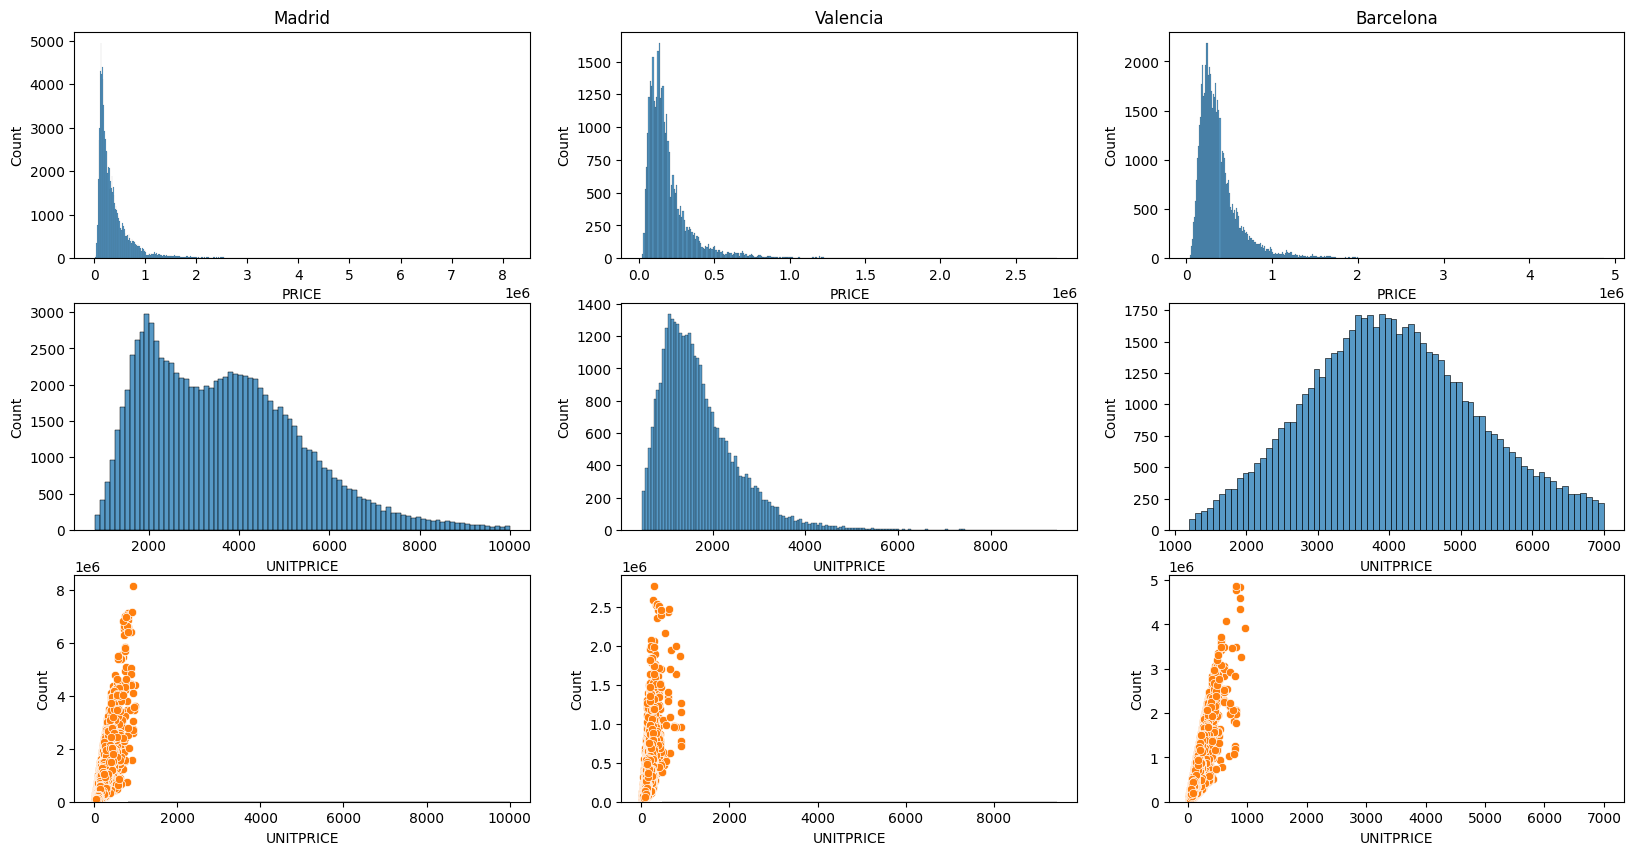

In [145]:
df=df[(df['DISTANCE_TO_CITY_CENTER']<150)]
ciudades=df['CITYNAME'].unique()
plt.figure(figsize=(20,10))
for i,c in enumerate(ciudades):
    plt.subplot(3,len(ciudades),(i+1))
    sns.histplot(
        x='PRICE',
        data=df[df['CITYNAME']==c]
    )
    plt.title(c)
    plt.subplot(3,len(ciudades),(i+4))
    sns.histplot(
        x='UNITPRICE',
        data=df[df['CITYNAME']==c]
    )
    plt.subplot(3,len(ciudades),(i+7))
    sns.histplot(
        x='UNITPRICE',
        data=df[df['CITYNAME']==c]
    )
    sns.scatterplot(
        x='CONSTRUCTEDAREA',
        y='PRICE',
        data=df[df['CITYNAME']==c]
    )
plt.show()

<Axes: xlabel='LATITUDE', ylabel='UNITPRICE'>

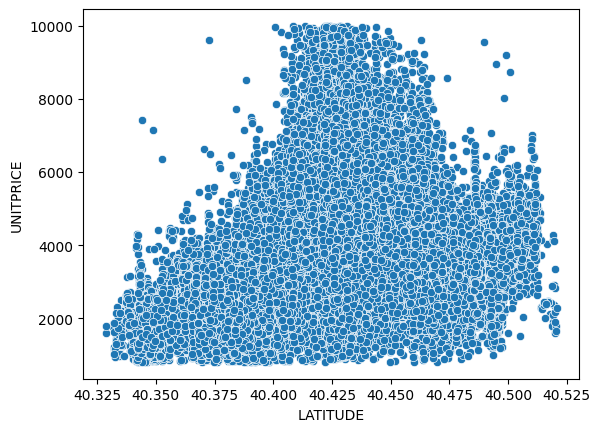

In [ ]:
sns.scatterplot(
    x='LATITUDE',
    y='UNITPRICE',
    data=df[(df['CITYNAME']=='Madrid')]
)

In [ ]:
df[df['CITYNAME']=='Madrid'].corr(numeric_only=True)['UNITPRICE'].sort_values(ascending=False).iloc[1:]

PRICE                            0.587778
LATITUDE                         0.353555
HASLIFT                          0.344307
BATHNUMBER                       0.284811
HASDOORMAN                       0.282570
CONSTRUCTEDAREA                  0.218207
FLATLOCATIONID                   0.192231
HASAIRCONDITIONING               0.191496
HASWARDROBE                      0.166984
CADMAXBUILDINGFLOOR              0.153374
FLOORCLEAN                       0.137949
ISSTUDIO                         0.075547
ISPARKINGSPACEINCLUDEDINPRICE    0.066013
HASPARKINGSPACE                  0.066013
HASWESTORIENTATION               0.065357
PERIOD                           0.059759
PARKINGSPACEPRICE                0.058724
HASBOXROOM                       0.049962
HASSWIMMINGPOOL                  0.048582
HASSOUTHORIENTATION              0.047150
BUILTTYPEID_3                    0.037115
HASEASTORIENTATION               0.036981
HASNORTHORIENTATION              0.031037
BUILTTYPEID                      0

In [59]:
df.corr(numeric_only=True)['PRICE'].sort_values(ascending=False).iloc[1:]

CONSTRUCTEDAREA                  0.813610
BATHNUMBER                       0.679470
UNITPRICE                        0.600964
ROOMNUMBER                       0.407260
HASDOORMAN                       0.347110
HASLIFT                          0.267227
HASPARKINGSPACE                  0.235096
ISPARKINGSPACEINCLUDEDINPRICE    0.235096
HASBOXROOM                       0.221846
LATITUDE                         0.168270
HASAIRCONDITIONING               0.146876
HASTERRACE                       0.135932
HASWARDROBE                      0.132160
CADMAXBUILDINGFLOOR              0.122852
FLOORCLEAN                       0.121371
HASSWIMMINGPOOL                  0.118015
HASGARDEN                        0.100398
HASSOUTHORIENTATION              0.085427
ISDUPLEX                         0.068187
HASWESTORIENTATION               0.064670
PARKINGSPACEPRICE                0.056038
BUILTTYPEID_2                    0.044828
ISINTOPFLOOR                     0.036633
HASEASTORIENTATION               0